<a href="https://colab.research.google.com/github/Protmdd/BD_OECE_PROYECTO_DM/blob/main/Copia_de_ENTREGA_3_Proyecto_DM_OECE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##GRUPO DIAMOND FINDERS ©

INTEGRANTES:

*Gianella Silvestre Nina   
*Andre de la Fuente   
*Luis Atto Pintado

**Actividad ❤**

*Descripción del problema y unidad de análisis.

*Fuentes de datos usadas y llave posible de integración.

*Tabla resumen de cada fuente: tamaño, tipos, faltantes, valores distintos y ejemplos de valores.

*Problemas detectados: valores faltantes; duplicados; errores de registro; tipos incorrectos; valores fuera de rango; posibles outliers; categorías no uniformes.

*Decisiones de limpieza justificadas: qué se corrigió; qué se imputó; qué se eliminó; qué se mantuvo y por qué.

*Base integrada inicial o plan claro de integración.

**1 DESCRIPCIÓN DEL PROBLEMA Y UNIDAD DE ANÁLISIS.** :

TITULO: **Segmentación de proveedores en contrataciones de municipalidades provinciales del Perú según patrones de participación y adjudicación, 2021–2025**

**Problema**

Los proveedores que participan en contrataciones de municipalidades provinciales presentan comportamientos heterogéneos en frecuencia de participación, experiencia, alcance territorial, tasa de adjudicación y montos obtenidos.

Sin embargo, la información del SEACE se encuentra distribuida entre miles de registros de convocatorias, ofertantes y adjudicaciones individuales, por lo que no es evidente qué tipos de proveedores conforman este mercado ni qué características los diferencian.

**Pregunta principal**

*¿Qué segmentos naturales de proveedores pueden identificarse en las contrataciones de municipalidades provinciales del Perú y qué características definen a cada perfil?*

**Unidad de análisis:** proveedor. Cada fila representará a un proveedor y resumirá su comportamiento histórico de participación y adjudicación en contrataciones municipales entre 2021 y 2025.

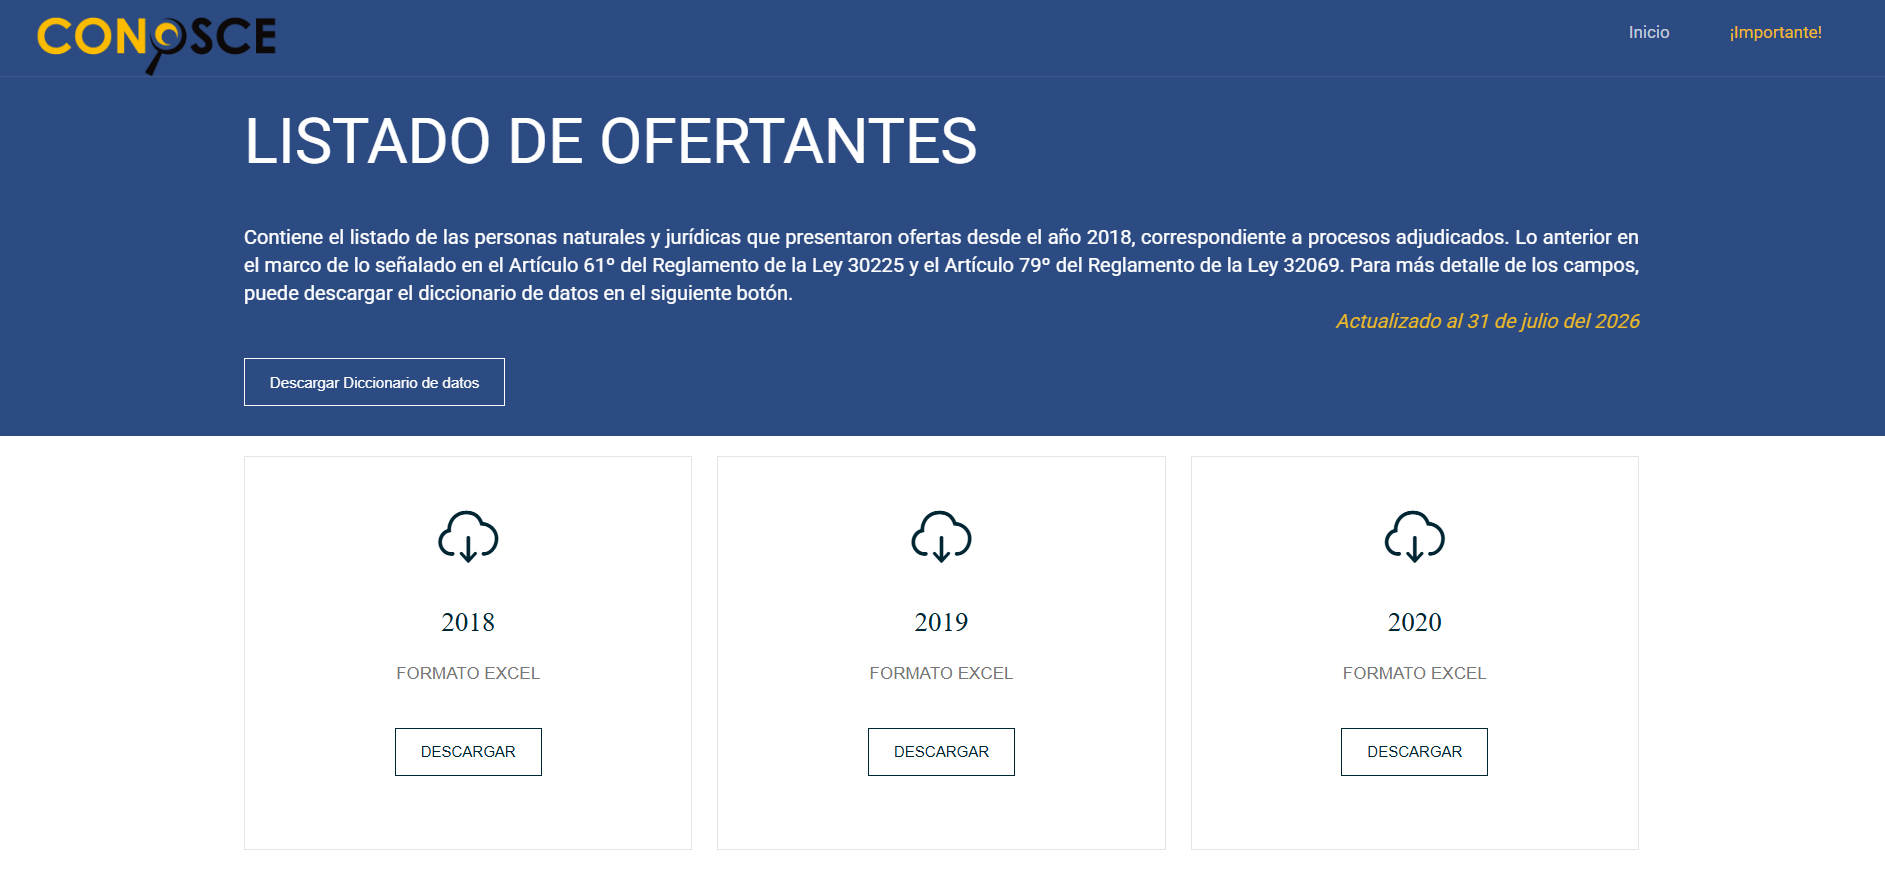

**2 FUENTES DE DATOS USADAS Y LLAVE POSIBLE DE INTEGRACIÓN.**

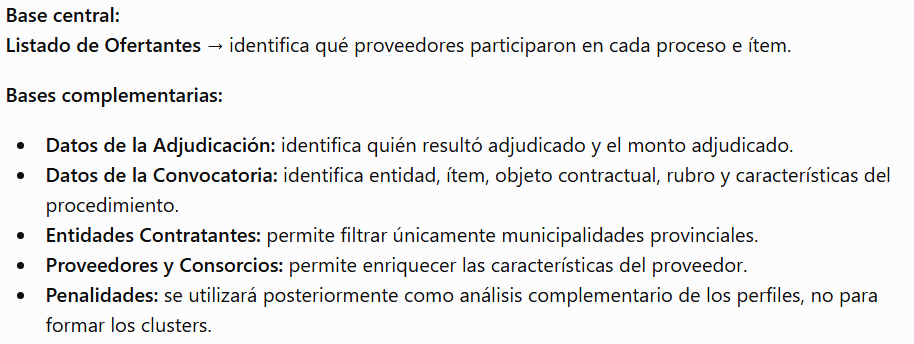

In [ ]:
# ============================================================
# DESCARGAR DATOS DESDE GITHUB
# ============================================================
import os
if not os.path.exists("/content/BD_OECE_PROYECTO_DM"):
    !git clone https://github.com/Protmdd/BD_OECE_PROYECTO_DM.git

try:
    import python_calamine
except ImportError:
    !pip install -q python-calamine

# ============================================================
# LECTURA Y CONCATENACIÓN MULTI-AÑO
# ============================================================
import glob, warnings, unicodedata, re, json
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

BASE = "/content/BD_OECE_PROYECTO_DM/Bases de Datos Proyecto DM"
CACHE = "/content/cache"
OUTPUT_DIR = "/content"
os.makedirs(CACHE, exist_ok=True)

# ------------------------------------------------------------
# 0) Normalizador de nombres de columna
# ------------------------------------------------------------
def norm_cols(df):
    def limpia(c):
        c = str(c).strip()
        c = unicodedata.normalize('NFKD', c).encode('ascii', 'ignore').decode('ascii')
        c = c.lower()
        c = c.replace('/', '_').replace('-', '_')
        c = '_'.join(c.split())
        c = ''.join(ch for ch in c if ch.isalnum() or ch == '_')
        return c.strip('_')
    df = df.copy()
    df.columns = [limpia(c) for c in df.columns]
    df = df.loc[:, ~df.columns.str.startswith('unnamed')]
    df = df.dropna(axis=1, how='all')
    df = df.rename(columns={'ano': 'anio', 'ao': 'anio'})

    # antes se descartaban columnas duplicadas sin avisar (dos columnas de origen
    # distinto pueden terminar con el mismo nombre tras normalizar tildes/espacios)
    dup_mask = df.columns.duplicated()
    if dup_mask.any():
        print(f"  ⚠ columnas duplicadas tras normalizar nombres, se descarta la repetida: {sorted(set(df.columns[dup_mask]))}")
    df = df.loc[:, ~dup_mask]
    return df


# ------------------------------------------------------------
# 0.1) Deduplicación por llave de integración, con reporte explícito
#      (se usa antes de cada merge para no inflar filas silenciosamente)
# ------------------------------------------------------------
def dedup_por_llave(df, llave, nombre):
    dup_mask = df.duplicated(subset=llave, keep=False)
    n_filas_dup = dup_mask.sum()
    if n_filas_dup == 0:
        print(f"  {nombre}: llave {llave} única, sin duplicados.")
        return df

    n_llaves_dup = df.loc[dup_mask, llave].drop_duplicates().shape[0]
    print(f"  {nombre}: {n_llaves_dup:,} llaves con más de un registro ({n_filas_dup:,} filas afectadas).")

    # si las filas repetidas son 100% idénticas en todas las columnas, es un
    # duplicado de registro real y se puede colapsar sin perder información
    n_antes = len(df)
    df = df.drop_duplicates()
    print(f"    filas colapsadas por ser duplicado exacto: {n_antes - len(df):,}")

    # lo que sigue con la misma llave pero contenido distinto no se puede resolver
    # automáticamente sin perder información -> se deja explícito para revisión manual,
    # y el merge posterior SÍ va a multiplicar esas filas si no se corrige a mano
    restantes = df.duplicated(subset=llave, keep=False).sum()
    if restantes > 0:
        print(f"    ⚠ quedan {restantes:,} filas con llave repetida pero contenido distinto -> revisar manualmente antes del merge.")
    return df


# ------------------------------------------------------------
# 1) Lector multi-año de Excel con cache en Parquet
#    (el cache ahora se invalida si la lista de archivos fuente cambió,
#    no solo si existe un .parquet con ese nombre)
# ------------------------------------------------------------
def leer_multianio(patron, base=BASE, agregar_anio=True, usar_cache=True):
    cache_file = os.path.join(CACHE, patron.replace('*', '').replace('.xlsx', '') + '.parquet')
    meta_file = cache_file.replace('.parquet', '_meta.json')

    files = sorted(glob.glob(os.path.join(base, patron)))
    archivos_actuales = sorted(os.path.basename(f) for f in files)

    if usar_cache and os.path.exists(cache_file) and os.path.exists(meta_file):
        with open(meta_file) as fh:
            meta_previo = json.load(fh)
        if meta_previo.get('archivos') == archivos_actuales:
            out = pd.read_parquet(cache_file)
            print(f"  ⚡ leído desde cache: {cache_file} -> {out.shape[0]:,} filas x {out.shape[1]} cols\n")
            return out
        else:
            print(f"  ⚠ cache desactualizado para '{patron}' (cambió la lista de archivos fuente), releyendo...")

    if not files:
        print(f"  Sin archivos para el patrón: {patron}")
        return pd.DataFrame()

    dfs, sets_cols = [], []
    for f in files:
        nombre = os.path.basename(f)
        df = norm_cols(pd.read_excel(f, engine='calamine'))

        if agregar_anio:
            digits = ''.join(ch for ch in nombre if ch.isdigit())
            df['anio_archivo'] = digits[:4] if len(digits) >= 4 else None
            df['archivo_origen'] = nombre

        sets_cols.append(set(df.columns))
        print(f"  ✔ {nombre:<48} -> {df.shape[0]:>9,} filas | {df.shape[1]:>2} cols")
        dfs.append(df)

    comunes, todas = set.intersection(*sets_cols), set.union(*sets_cols)
    if todas - comunes:
        print(f"  Columnas no presentes en todos los años: {sorted(todas - comunes)}")

    out = pd.concat(dfs, ignore_index=True, sort=False)
    print(f"  ➜ CONCATENADO: {out.shape[0]:,} filas x {out.shape[1]} cols\n")

    if usar_cache:
        out.to_parquet(cache_file)
        with open(meta_file, 'w') as fh:
            json.dump({'archivos': archivos_actuales}, fh)

    return out


# ------------------------------------------------------------
# 2) Lector de PENALIDADES (vectorizado, con reparación solo para filas rotas)
#    Estructura: ID CONTRATO|RUC CONTRATISTA|TIPO PENALIDAD|OBJETO CONTRATO|
#                ENTIDAD CONTRATANTE|FECHA PENALIDAD|DESCRIPCION/MOTIVO|MONTO
# ------------------------------------------------------------
def leer_penalidades(nombre="penalidades.csv", base=BASE, sep='|',
                     col_texto=6, encodings=('utf-8', 'utf-8-sig', 'latin-1'),
                     usar_cache=True):
    cache_file = os.path.join(CACHE, 'penalidades.parquet')
    if usar_cache and os.path.exists(cache_file):
        df = pd.read_parquet(cache_file)
        print(f"  ⚡ leído desde cache: {cache_file} -> {df.shape[0]:,} filas | {df.shape[1]} cols\n")
        return df

    ruta = os.path.join(base, nombre)

    for enc in encodings:
        try:
            with open(ruta, 'r', encoding=enc) as fh:
                lineas = fh.read().splitlines()
            break
        except UnicodeDecodeError:
            continue

    header = [h.strip() for h in lineas[0].split(sep)]
    ncol = len(header)
    body = pd.Series([l for l in lineas[1:] if l.strip()])

    # separa filas bien formadas (vectorizado) de las rotas (loop solo ahí)
    n_pipes = body.str.count(re.escape(sep))
    ok_mask = n_pipes == (ncol - 1)

    df_ok = body[ok_mask].str.split(sep, expand=True)
    df_ok.columns = header
    df_ok['fila_incompleta'] = False

    # OJO: las filas de este bloque NO se descartan del dataset final, se
    # rellenan con None y de todas formas se concatenan (df_mal + df_ok).
    # 'incompletas_rellenadas' refleja eso; se agrega además una columna
    # 'fila_incompleta' para poder filtrarlas explícitamente más adelante
    # si se decide que no son confiables.
    filas_mal, reparadas, incompletas_rellenadas = [], 0, 0
    for ln in body[~ok_mask]:
        p = ln.split(sep)
        if len(p) > ncol:
            n_extra = len(p) - ncol
            p = (p[:col_texto]
                 + [sep.join(p[col_texto: col_texto + 1 + n_extra])]
                 + p[col_texto + 1 + n_extra:])
            reparadas += 1
        else:
            p = p + [None] * (ncol - len(p))
            incompletas_rellenadas += 1
        filas_mal.append(p)

    df_mal = pd.DataFrame(filas_mal, columns=header) if filas_mal else pd.DataFrame(columns=header)
    df_mal['fila_incompleta'] = True

    df = pd.concat([df_ok, df_mal], ignore_index=True)
    cols_texto = [c for c in df.columns if c != 'fila_incompleta']
    df[cols_texto] = df[cols_texto].apply(lambda c: c.str.strip() if c.dtype == 'object' else c)
    # norm_cols descarta columnas duplicadas por nombre; fila_incompleta ya tiene nombre único
    df = norm_cols(df)

    # tipos
    df['monto'] = pd.to_numeric(df['monto'], errors='coerce')
    df['fecha_penalidad'] = pd.to_datetime(df['fecha_penalidad'],
                                           format='%d/%m/%y', errors='coerce')
    df['ruc_contratista'] = (df['ruc_contratista'].astype(str)
                             .str.replace(r'\.0$', '', regex=True).str.strip())

    print(f"  ✔ {nombre} (enc={enc}) -> {df.shape[0]:,} filas | {df.shape[1]} cols")
    print(f"     filas reparadas (| extra): {reparadas:,} | filas incompletas rellenadas con None: {incompletas_rellenadas:,}")
    print(f"     columnas: {list(df.columns)}\n")

    if usar_cache:
        df.to_parquet(cache_file)

    return df


# ------------------------------------------------------------
# 3) Lector de CSV simple (entidades)
# ------------------------------------------------------------
def leer_csv(nombre, base=BASE, sep='|'):
    ruta = os.path.join(base, nombre)
    for enc in ('utf-8', 'utf-8-sig', 'latin-1'):
        try:
            df = norm_cols(pd.read_csv(ruta, sep=sep, encoding=enc,
                                       engine='python', on_bad_lines='skip', dtype=str))
            print(f"  ✔ {nombre} (enc={enc}) -> {df.shape[0]:,} filas | {df.shape[1]} cols\n")
            return df
        except UnicodeDecodeError:
            continue
    raise ValueError(f"No se pudo leer {nombre}")


# ============================================================
# GENERACIÓN DE LOS DATAFRAMES
# ============================================================
print("📂 ADJUDICACIONES:");  df_adj  = leer_multianio("CONOSCE_ADJUDICACIONES*.xlsx")
print("📂 POSTORES:");        df_post = leer_multianio("CONOSCE_POSTOR*.xlsx")
print("📂 CONSORCIOS:");      df_cons = leer_multianio("CONOSCE_CONSORCIO*.xlsx")
print("📂 CONVOCATORIAS:");   df_conv = leer_multianio("CONOSCE_CONVOCATORIAS*.xlsx")
print("📂 ENTIDADES:");       df_ent  = leer_csv("entidades_contratantes.csv")
print("📂 PENALIDADES:");     df_pen  = leer_penalidades("penalidades.csv")


# ============================================================
# RESUMEN + VERIFICACIÓN
# ============================================================
dfs = {'df_adj': df_adj, 'df_post': df_post, 'df_cons': df_cons,
       'df_conv': df_conv, 'df_ent': df_ent, 'df_pen': df_pen}

resumen_dfs = pd.DataFrame([{'DataFrame': k,
                             'Filas': v.shape[0],
                             'Columnas': v.shape[1],
                             'MB': round(v.memory_usage(deep=True).sum() / 1e6, 1)}
                            for k, v in dfs.items()])

print("=" * 70)
print("RESUMEN DE DATAFRAMES GENERADOS")
print("=" * 70)
print(resumen_dfs.to_string(index=False))

for k, v in dfs.items():
    print(f"\n{k} ({v.shape[0]:,} x {v.shape[1]}):\n  {list(v.columns)}")

for nombre, d in [('ADJUDICACIONES', df_adj), ('POSTORES', df_post),
                  ('CONSORCIOS', df_cons), ('CONVOCATORIAS', df_conv)]:
    if 'anio_archivo' in d.columns:
        print(f"\n{nombre} — registros por año:")
        print(d['anio_archivo'].value_counts().sort_index().to_string())


Cloning into 'BD_OECE_PROYECTO_DM'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 26 (delta 0), reused 26 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), done.
Filtering content: 100% (22/22), 237.44 MiB | 72.43 MiB/s, done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 18.6 MB/s eta 0:00:00
📂 ADJUDICACIONES:
  ✔ CONOSCE_ADJUDICACIONES2021_0.xlsx                ->    58,721 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2022_0.xlsx                ->    68,153 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2023_0.xlsx                ->    68,464 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2024_0.xlsx                ->    67,466 filas | 27 cols
  ✔ CONOSCE_ADJUDICACIONES2025_0.xlsx                ->    63,966 filas | 27 cols
  ➜ CONCATENADO: 326,770 filas x 27 cols

📂 POSTORES:
  ✔ CONOSCE_POSTOR2021_0.xlsx                        ->   182,382 filas |  8 cols
  ✔ CON

**POSIBLE LLAVE DE INTEGRACIÓN.**

**Columnas en df_post (Listado de Ofertantes):**

['codigo_convocatoria', 'fechaconvocatoria', 'n_item', 'ruc_codigo_postor', 'postor', 'fecha_presentacion_propuesta', 'anio_archivo', 'archivo_origen']


--- **Columnas comunes con otros DataFrames** ---

df_post y df_adj (Adjudicaciones): ['anio_archivo', 'archivo_origen', 'n_item']

df_post y df_cons (Consorcios): ['anio_archivo', 'archivo_origen']

df_post y df_conv (Convocatorias): ['anio_archivo', 'archivo_origen', 'n_item']

df_post y df_ent (Entidades): []

df_post y df_pen (Penalidades): []


Análisis de Llaves de Integración Sugeridas:
  - `codigo_convocatoria`: Clave para integrar `df_post` con `df_adj` y `df_conv`.
  - `ruc_codigo_postor` (en `df_post`) / `ruc_contratista` (en `df_pen`): Podrían ser RUCs de proveedores/contratistas.
  - `anio_archivo`: Útil para integrar por año, aunque ya está presente en casi todos los DataFrames.


**3 RESUMEN DE CADA FUENTE**

### Resumen Detallado por Fuente de Datos
A continuación, se presenta un resumen exhaustivo para cada DataFrame, que incluye:
*   **Dimensiones:** Número de filas y columnas.
*   **Tipos de Datos:** El tipo de dato inferido por Pandas para cada columna.
*   **Valores Faltantes:** Conteo y porcentaje de valores nulos por columna.
*   **Valores Distintos:** El número de valores únicos en cada columna.
*   **Ejemplos de Valores:** Las primeras 5 filas del DataFrame para una vista rápida de los datos.

In [ ]:
def summarize_dataframe_full(df, name):
    print(f"\n{'='*70}\nRESUMEN COMPLETO PARA: {name}\n{'='*70}")

    # Dimensiones
    print(f"\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

    # Tipos de Datos
    print("\nTipos de Datos:")
    display(df.dtypes.to_frame(name='Tipo de Dato'))

    # Valores Faltantes
    missing_count = df.isnull().sum()
    missing_pct = (df.isnull().mean() * 100).round(2)
    missing_info = pd.DataFrame({'Faltantes': missing_count, 'Porcentaje': missing_pct})
    missing_info = missing_info[missing_info['Faltantes'] > 0]
    if not missing_info.empty:
        print("\nValores Faltantes:")
        display(missing_info.sort_values(by='Faltantes', ascending=False))
    else:
        print("\nNo hay valores faltantes en este DataFrame.")

    # Valores Distintos
    print("\nValores Distintos por Columna:")
    display(df.nunique().to_frame(name='Valores Únicos'))

    # Ejemplos de Valores
    print("\nEjemplos de Valores (primeras 5 filas):")
    display(df.head())


# Aplicar la función a cada DataFrame
for name, df in dfs.items():
    summarize_dataframe_full(df, name)


RESUMEN COMPLETO PARA: df_adj

Dimensiones: 326,770 filas x 27 columnas

Tipos de Datos:


,Tipo de Dato
codigoentidad,int64
entidad_ruc,int64
entidad,object
tipoentidad,object
entidad_departamento,object
codigoconvocatoria,int64
objetocontractual,object
tipoprocesoseleccion,object
proceso,object
descripcion_proceso,object



Valores Faltantes:


,Faltantes,Porcentaje
fecha_consentimiento_bp,2914,0.89
departamento_item,1657,0.51
fecha_buenapro,80,0.02
monto_referencial_item_soles,3,0.00
tipo_proveedor,1,0.00



Valores Distintos por Columna:


...

,Faltantes,Porcentaje
monto,7332,52.38
tipo_penalidad,1,0.01
objeto_contrato,1,0.01
entidad_contratante,1,0.01
fecha_penalidad,1,0.01
descripcion_motivo,1,0.01



Valores Distintos por Columna:


,Valores Únicos
id_contrato,5125
ruc_contratista,3233
tipo_penalidad,2
objeto_contrato,4
entidad_contratante,628
fecha_penalidad,1581
descripcion_motivo,8361
monto,1938
fila_incompleta,2



Ejemplos de Valores (primeras 5 filas):


,id_contrato,ruc_contratista,tipo_penalidad,objeto_contrato,entidad_contratante,fecha_penalidad,descripcion_motivo,monto,fila_incompleta
0,2255476,20536426168,Otra Penalidad,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2026-03-10,PENALIDAD POR INCIDENCIA ADMINISTRATIVA ASOCIA...,220.0,False
1,2330522,20553404631,Por Mora,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2025-08-05,SE REGISTRA LA APLICACION DE PENALIDAD EN FUNC...,NaN,False
2,2330522,20553404631,Por Mora,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2025-08-27,SE REGISTRA LA APLICACION DE PENALIDAD EN FUNC...,NaN,False
3,2320073,20536426168,Otra Penalidad,Servicio,PROYECTO ESPECIAL DE INVERSION PUBLICA ESCUELA...,2026-03-25,PENALIDAD POR INCIDENCIA ADMINISTRATIVA ASOCIA...,220.0,False
4,2234695,10283047682,Otra Penalidad,Consultoría de Obra,MUNICIPALIDAD DISTRITAL DE MEGANTONI,2025-02-15,APLICACION DE PENALIDAD,2575.0,False


**4 PROBLEMAS DETECTADOS: valores faltantes; duplicados; errores de registro; tipos incorrectos; valores fuera de rango; posibles outliers; categorías no uniformes.**

## Detección Específica de Problemas de Calidad de Datos

### 1. Valores Faltantes (Missing Values)

In [ ]:
print("\n--- df_adj: Adjudicaciones ---")
missing_adj = df_adj.isnull().sum()
missing_adj = missing_adj[missing_adj > 0]
if not missing_adj.empty:
    missing_adj_pct = (missing_adj / len(df_adj)) * 100
    missing_adj_df = pd.DataFrame({'Count': missing_adj, 'Percentage': missing_adj_pct})
    display(missing_adj_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_adj.")

print("\n--- df_post: Postores ---")
missing_post = df_post.isnull().sum()
missing_post = missing_post[missing_post > 0]
if not missing_post.empty:
    missing_post_pct = (missing_post / len(df_post)) * 100
    missing_post_df = pd.DataFrame({'Count': missing_post, 'Percentage': missing_post_pct})
    display(missing_post_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_post.")

print("\n--- df_cons: Consorcios ---")
missing_cons = df_cons.isnull().sum()
missing_cons = missing_cons[missing_cons > 0]
if not missing_cons.empty:
    missing_cons_pct = (missing_cons / len(df_cons)) * 100
    missing_cons_df = pd.DataFrame({'Count': missing_cons, 'Percentage': missing_cons_pct})
    display(missing_cons_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_cons.")

print("\n--- df_conv: Convocatorias ---")
missing_conv = df_conv.isnull().sum()
missing_conv = missing_conv[missing_conv > 0]
if not missing_conv.empty:
    missing_conv_pct = (missing_conv / len(df_conv)) * 100
    missing_conv_df = pd.DataFrame({'Count': missing_conv, 'Percentage': missing_conv_pct})
    display(missing_conv_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_conv.")

print("\n--- df_ent: Entidades ---")
missing_ent = df_ent.isnull().sum()
missing_ent = missing_ent[missing_ent > 0]
if not missing_ent.empty:
    missing_ent_pct = (missing_ent / len(df_ent)) * 100
    missing_ent_df = pd.DataFrame({'Count': missing_ent, 'Percentage': missing_ent_pct})
    display(missing_ent_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_ent.")

print("\n--- df_pen: Penalidades ---")
missing_pen = df_pen.isnull().sum()
missing_pen = missing_pen[missing_pen > 0]
if not missing_pen.empty:
    missing_pen_pct = (missing_pen / len(df_pen)) * 100
    missing_pen_df = pd.DataFrame({'Count': missing_pen, 'Percentage': missing_pen_pct})
    display(missing_pen_df.sort_values(by='Count', ascending=False))
else:
    print("No hay valores faltantes en df_pen.")


--- df_adj: Adjudicaciones ---


,Count,Percentage
fecha_consentimiento_bp,2914,0.891759
departamento_item,1657,0.507084
fecha_buenapro,80,0.024482
monto_referencial_item_soles,3,0.000918
tipo_proveedor,1,0.000306



--- df_post: Postores ---
No hay valores faltantes en df_post.

--- df_cons: Consorcios ---
No hay valores faltantes en df_cons.

--- df_conv: Convocatorias ---


,Count,Percentage
fechaintegracionbases,124256,38.265583
codigoitem,49587,15.270695
itemcubso,49587,15.270695
fechapresentacionpropuesta,39562,12.183420
distrito_item,1653,0.509054
departamento_item,1653,0.509054
provincia_item,1653,0.509054
sistema_contratacion,68,0.020941



--- df_ent: Entidades ---


,Count,Percentage
codigo_siaf,352,10.466845



--- df_pen: Penalidades ---


,Count,Percentage
monto,7332,52.375170
tipo_penalidad,1,0.007143
objeto_contrato,1,0.007143
entidad_contratante,1,0.007143
fecha_penalidad,1,0.007143
descripcion_motivo,1,0.007143


### 2. Duplicados

In [ ]:
print("### Detección de Filas Duplicadas ###\n")

# Apply necessary renames for duplication check
# These renames are crucial because subsequent lines rely on these new column names.
# Based on the kernel state, df_conv, df_adj, and df_post still have their original column names.
df_conv = df_conv.rename(columns={'codigoconvocatoria': 'codigo_convocatoria'})
df_adj = df_adj.rename(columns={'codigoconvocatoria': 'codigo_convocatoria'})
df_post = df_post.rename(columns={'ruc_codigo_postor': 'ruc_proveedor'})


for name, df in dfs.items():
    total_duplicados = df.duplicated().sum()
    if total_duplicados > 0:
        print(f"DataFrame '{name}': {total_duplicados:,} filas completamente duplicadas.")
    else:
        print(f"DataFrame '{name}': No se encontraron filas completamente duplicadas.")

# Penalidades: los duplicados exactos SÍ se eliminan aquí, antes de cualquier
# groupby, para no contar la misma penalidad (y su monto) más de una vez.
n_dup_pen = df_pen.duplicated().sum()
if n_dup_pen > 0:
    print(f"\ndf_pen: eliminando {n_dup_pen:,} filas completamente duplicadas antes de usarlas en agregaciones.")
    df_pen = df_pen.drop_duplicates().reset_index(drop=True)
    dfs['df_pen'] = df_pen

# Duplicados por llave de integración (no por fila completa). Si aquí aparece
# algo > 0, el merge de la sección de integración va a inflar filas si no se
# resuelve antes (ver dedup_por_llave en la celda de integración Nivel 1).
print("\nDuplicados por llave de integración (antes de mergear):")
print(f"  df_conv por (codigo_convocatoria, n_item): {df_conv.duplicated(['codigo_convocatoria', 'n_item']).sum():,}")
print(f"  df_adj  por (codigo_convocatoria, n_item): {df_adj.duplicated(['codigo_convocatoria', 'n_item']).sum():,}")
print(f"  df_post por (codigo_convocatoria, n_item, ruc_proveedor): {df_post.duplicated(['codigo_convocatoria', 'n_item', 'ruc_proveedor']).sum():,}")

### Detección de Filas Duplicadas ###

DataFrame 'df_adj': No se encontraron filas completamente duplicadas.
DataFrame 'df_post': No se encontraron filas completamente duplicadas.
DataFrame 'df_cons': No se encontraron filas completamente duplicadas.
DataFrame 'df_conv': No se encontraron filas completamente duplicadas.
DataFrame 'df_ent': No se encontraron filas completamente duplicadas.
DataFrame 'df_pen': 367 filas completamente duplicadas.

df_pen: eliminando 367 filas completamente duplicadas antes de usarlas en agregaciones.

Duplicados por llave de integración (antes de mergear):
  df_conv por (codigo_convocatoria, n_item): 0
  df_adj  por (codigo_convocatoria, n_item): 2,050
  df_post por (codigo_convocatoria, n_item, ruc_proveedor): 292


### 3. Tipos Incorrectos y Errores de Registro (Coerción a NaN/NaT)

In [ ]:
print("### Detección de Errores de Tipo y Coerción ###\n")
def check_type_coercion(df, df_name):
    # columnas que por su nombre/uso deberían ser numéricas o fecha.
    # 'ruc' se excluye a propósito: el RUC se trata como texto (para no perder
    # ceros a la izquierda, ver celda de estandarización de llaves), así que
    # marcarlo como "error" cuando no es numérico sería un falso positivo.
    cols_esperado_numerico = [c for c in df.columns
                               if any(k in c.lower() for k in ['monto', 'cantidad', 'codigo', 'n_item'])
                               and 'ruc' not in c.lower()]
    cols_esperado_fecha    = [c for c in df.columns if 'fecha' in c.lower()]

    for col in cols_esperado_numerico:
        if pd.api.types.is_numeric_dtype(df[col].dtype):
            continue
        temp_numeric = pd.to_numeric(df[col], errors='coerce')
        numeric_errors = temp_numeric.isnull() & df[col].notnull()
        if numeric_errors.any():
            print(f"DataFrame '{df_name}', Columna '{col}' (Numérico): {numeric_errors.sum():,} valores no numéricos. Ejemplos: {df[col][numeric_errors].head().tolist()}")

    for col in cols_esperado_fecha:
        if pd.api.types.is_datetime64_any_dtype(df[col].dtype):
            continue
        temp_datetime = pd.to_datetime(df[col], errors='coerce')
        datetime_errors = temp_datetime.isnull() & df[col].notnull()
        if datetime_errors.any():
            print(f"DataFrame '{df_name}', Columna '{col}' (Fecha): {datetime_errors.sum():,} valores no-fecha. Ejemplos: {df[col][datetime_errors].head().tolist()}")

for name, df in dfs.items():
    print(f"Analizando DataFrame: {name}")
    check_type_coercion(df, name)
    print("-" * 50)


### Detección de Errores de Tipo y Coerción ###

Analizando DataFrame: df_adj
DataFrame 'df_adj', Columna 'descripcion_item' (Numérico): 326,735 valores no numéricos. Ejemplos: ['SERVICIO DE MANTENIMIENTO PREVENTIVO Y CORRECTIVO DE LA RED DE ENERGIA DE ALIMENTACION PARA LOS SISTEMAS DE AIRE ACONDICIONADO DE LAS 3 UCIS DEL HMC PP-135', 'BOLSA DE POLIETILENO BIODEGRADABLE VERDE DE 75 L', 'SUSCRIPCION A LA BASE DE DATOS E-LIBRO', 'CONTRATACION DE SERVICIO DE CONSULTORIA OBRA PARA LA ELABORACI¿N DE EXPEDIENTE T¿CNICO DEL PROYECTO ¿MEJORAMIENTO Y AMPLIACION DEL SERVICIO EDUCATIVO DE NIVEL INICIAL EN LA INSTITUCION EDUCATIVA N¿ 344 DE LA LOCALIDAD DE TACA, DEL DISTRITO DE CANARIA, PROVINCIA DE VICTOR FAJARDO, DEPARTAMENTO DE AYACUCHO¿', 'ELABORACI¿N DE EXPEDIENTE T¿CNICO:  ¿MEJORAMIENTO Y AMPLIACION DEL SERVICIO EDUCATIVO DEL NIVEL SECUNDARIO DE LA I.E. NUESTRA SE¿ORA DEL CARMEN DEL DISTRITO DE IMPERIAL, PROVINCIA DE CA¿ETE, DEPARTAMENTO DE LIMA¿ CUI N¿ 2338999']
DataFrame 'df_adj', Columna 

### 4. Valores Fuera de Rango y Outliers (Valores Atípicos)

In [ ]:
print("### Detección de Outliers (IQR) y Valores Fuera de Rango (Heurístico) ###\n")

def es_columna_id_o_binaria(col, serie):
    """Columnas identificadoras (codigo/ruc/n_item/anio) o binarias 0/1:
    el IQR no tiene interpretación estadística sobre ellas."""
    nombre = col.lower()
    if any(p in nombre for p in ['codigo', 'ruc', 'n_item', 'anio', 'id_']):
        return True
    valores = serie.dropna().unique()
    if len(valores) > 0 and set(valores).issubset({0, 1}):
        return True
    return False

def detect_outliers_and_range(df, df_name):
    print(f"Analizando DataFrame: {df_name}")
    numerical_cols = df.select_dtypes(include=['number']).columns

    for col in numerical_cols:
        if es_columna_id_o_binaria(col, df[col]):
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

        if not outliers.empty:
            # los outliers se reportan como alerta para revisión, no se eliminan
            # automáticamente: un proveedor con montos/participaciones muy altos
            # puede ser un caso real relevante para el clustering.
            print(f"Columna '{col}': {len(outliers):,} valores atípicos (IQR) detectados. Ejemplos: {outliers.head().tolist()}")

        if 'monto' in col or 'cantidad' in col:
            negative_values = df[df[col] < 0][col]
            if not negative_values.empty:
                print(f"Columna '{col}': {len(negative_values):,} valores negativos detectados (fuera de rango esperado). Ejemplos: {negative_values.head().tolist()}")
    print("-" * 50)

for name, df in dfs.items():
    detect_outliers_and_range(df, name)


### Detección de Outliers (IQR) y Valores Fuera de Rango (Heurístico) ###

Analizando DataFrame: df_adj
Columna 'cantidad_adjudicado_item': 72,612 valores atípicos (IQR) detectados. Ejemplos: [539339.0, 1120.0, 3220.14, 94899.0, 96720.0]
Columna 'monto_referencial_item_soles': 45,619 valores atípicos (IQR) detectados. Ejemplos: [1240479.7, 1360219.0, 3060372.0, 4000000.0, 1830000.0]
Columna 'monto_adjudicado_item_soles': 44,507 valores atípicos (IQR) detectados. Ejemplos: [1342504.5, 3060372.0, 826560.0, 3456789.0, 1830000.0]
--------------------------------------------------
Analizando DataFrame: df_post
--------------------------------------------------
Analizando DataFrame: df_cons
--------------------------------------------------
Analizando DataFrame: df_conv
Columna 'montoreferencial': 48,946 valores atípicos (IQR) detectados. Ejemplos: [2389158.48, 1347287.01, 7856400.0, 21537948.12, 6561500.0]
Columna 'monto_referencial_item': 44,355 valores atípicos (IQR) detectados. Ejemplos:

### 5. Categorías Raras e Inconsistencias (Value Counts)

In [ ]:
# REVISIÓN DE CATEGORÍAS RARAS / POSIBLES INCONSISTENCIAS

def revisar_value_counts(df, nombre_df, max_unicos=50, top_n=15):
    """
    Revisa columnas categóricas con value_counts().

    - max_unicos: solo analiza columnas con hasta ese número de categorías.
    - top_n: muestra las categorías más frecuentes.

    No modifica el DataFrame.
    """

    print("\n" + "=" * 90)
    print(f"REVISIÓN DE CATEGORÍAS: {nombre_df}")
    print("=" * 90)

    columnas_cat = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for col in columnas_cat:

        n_unicos = df[col].nunique(dropna=True)

        # Evitar columnas tipo RUC, nombres, códigos, descripciones extensas
        if n_unicos > max_unicos:
            continue

        print(f"\n Variable: {col}")
        print(f"Valores únicos: {n_unicos}")

        conteos = df[col].value_counts(dropna=False)

        display(
            conteos.head(top_n).to_frame("frecuencia")
        )

Explorar cómo se distribuyen las categorías dentro de cada variable categórica y detectar visualmente valores que puedan llamar la atención.

In [ ]:
# APLICACIÓN A TODAS LAS BASES

bases = {
    "Listado de Ofertantes": df_post,
    "Datos de la Adjudicación": df_adj,
    "Datos de la Convocatoria": df_conv,
    "Entidades Contratantes": df_ent,
    "Consorcios": df_cons,
    "Penalidades": df_pen
}

for nombre, df in bases.items():
    revisar_value_counts(
        df,
        nombre_df=nombre,
        max_unicos=50,
        top_n=15
    )


REVISIÓN DE CATEGORÍAS: Listado de Ofertantes

 Variable: anio_archivo
Valores únicos: 5


,frecuencia
anio_archivo,
2024,244699
2023,224952
2022,199251
2025,198584
2021,182382



 Variable: archivo_origen
Valores únicos: 5


,frecuencia
archivo_origen,
CONOSCE_POSTOR2024_0.xlsx,244699
CONOSCE_POSTOR2023_0.xlsx,224952
CONOSCE_POSTOR2022_0.xlsx,199251
CONOSCE_POSTOR2025_0.xlsx,198584
CONOSCE_POSTOR2021_0.xlsx,182382



REVISIÓN DE CATEGORÍAS: Datos de la Adjudicación

 Variable: tipoentidad
Valores únicos: 5


...

,frecuencia
archivo_origen,
CONOSCE_CONSORCIO2025_0.xlsx,27930
CONOSCE_CONSORCIO2024_0.xlsx,27534
CONOSCE_CONSORCIO2023_0.xlsx,24092
CONOSCE_CONSORCIO2022_0.xlsx,5831
CONOSCE_CONSORCIO2021_0.xlsx,4192



REVISIÓN DE CATEGORÍAS: Penalidades

 Variable: tipo_penalidad
Valores únicos: 2


,frecuencia
tipo_penalidad,
Otra Penalidad,9193
Por Mora,4438
None,1



 Variable: objeto_contrato
Valores únicos: 4


,frecuencia
objeto_contrato,
Servicio,9819
Bien,1664
Obra,1250
Consultoría de Obra,898
None,1


Para detectar categorías raras específicamente

¿Qué categorías tienen una frecuencia muy baja y conviene revisar manualmente?

In [ ]:
# DETECCIÓN DE CATEGORÍAS POCO FRECUENTES
def detectar_categorias_raras(df, nombre_df, max_unicos=50, umbral=5):

    print("\n" + "=" * 90)
    print(f"CATEGORÍAS RARAS: {nombre_df}")
    print("=" * 90)

    columnas_cat = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for col in columnas_cat:

        n_unicos = df[col].nunique(dropna=True)

        if n_unicos > max_unicos:
            continue

        conteos = df[col].value_counts(dropna=False)

        raras = conteos[conteos <= umbral]

        if len(raras) > 0:

            print(f"\n Variable: {col}")
            print(f"Categorías con frecuencia <= {umbral}: {len(raras)}")

            display(
                raras.head(20).to_frame("frecuencia")
            )

In [ ]:
for nombre, df in bases.items():
    detectar_categorias_raras(
        df,
        nombre_df=nombre,
        max_unicos=50,
        umbral=5
    )


CATEGORÍAS RARAS: Listado de Ofertantes

CATEGORÍAS RARAS: Datos de la Adjudicación

 Variable: tipoprocesoseleccion
Categorías con frecuencia <= 5: 6


,frecuencia
tipoprocesoseleccion,
Concurso Público Abreviado - Ley N°26859,5
Concurso de Proyectos Arquitectónicos,4
Licitación Pública Abreviada Séptima DCF Ley N°32069,4
Adjudicación Simplificada-Decreto de Urgencia 114-2020,3
Concurso Público Abreviado - Ley N°31589,3
Adjudicación Simplificada-Decreto Legislativo N° 1355,1



 Variable: moneda
Categorías con frecuencia <= 5: 3


,frecuencia
moneda,
Dólar Canadiense,5
Real Brasileño,3
Franco Suizo,1



 Variable: unidad_medida
Categorías con frecuencia <= 5: 3


...

,frecuencia
moneda,
Dólar Canadiense,5
Real Brasileño,3
Franco Suizo,1



CATEGORÍAS RARAS: Entidades Contratantes

CATEGORÍAS RARAS: Consorcios

CATEGORÍAS RARAS: Penalidades

 Variable: tipo_penalidad
Categorías con frecuencia <= 5: 1


,frecuencia
tipo_penalidad,
None,1



 Variable: objeto_contrato
Categorías con frecuencia <= 5: 1


,frecuencia
objeto_contrato,
None,1


Detectar casos donde dos categorías podrían ser en realidad la misma, pero están escritas distinto por detalles de formato, sobre todo:

*mayúsculas/minúsculas;

*espacios al inicio o al final.

In [ ]:
# POSIBLES INCONSISTENCIAS DE ESCRITURA

def detectar_variantes_texto(df, nombre_df, max_unicos=50):

    print("\n" + "=" * 90)
    print(f"POSIBLES INCONSISTENCIAS DE TEXTO: {nombre_df}")
    print("=" * 90)

    columnas_cat = df.select_dtypes(
        include=["object", "string", "category"]
    ).columns

    for col in columnas_cat:

        serie = df[col].dropna().astype(str)

        if serie.nunique() > max_unicos:
            continue

        # Solo se usa para comparar, NO modifica el dataframe
        normalizada = serie.str.strip().str.upper()

        if normalizada.nunique() < serie.nunique():

            print(f"\n Variable: {col}")
            print(
                f"Categorías originales: {serie.nunique()} | "
                f"Después de ignorar espacios/mayúsculas: {normalizada.nunique()}"
            )

In [ ]:
for nombre, df in bases.items():
    detectar_variantes_texto(
        df,
        nombre_df=nombre,
        max_unicos=50
    )


POSIBLES INCONSISTENCIAS DE TEXTO: Listado de Ofertantes

POSIBLES INCONSISTENCIAS DE TEXTO: Datos de la Adjudicación

POSIBLES INCONSISTENCIAS DE TEXTO: Datos de la Convocatoria

POSIBLES INCONSISTENCIAS DE TEXTO: Entidades Contratantes

POSIBLES INCONSISTENCIAS DE TEXTO: Consorcios

POSIBLES INCONSISTENCIAS DE TEXTO: Penalidades


**5. DECISIONES DE LIMPIEZA JUSTIFICADAS: qué se corrigió; qué se imputó; qué se eliminó; qué se mantuvo y por qué.**





A partir del análisis de calidad realizado sobre las fuentes de datos, se tomaron las siguientes decisiones de limpieza y preparación. Las decisiones buscan conservar la mayor cantidad posible de información sin alterar el significado de las variables ni introducir valores artificiales.

### 5.1 ¿Qué se corrigió?

**Estandarización de las llaves de integración.**
Se corrigieron los nombres de las variables utilizadas como identificadores para que las seis fuentes pudieran integrarse correctamente. En particular, los identificadores del proveedor se estandarizaron bajo el nombre `ruc_proveedor`, mientras que los códigos de convocatoria se unificaron bajo `codigo_convocatoria`. También se estandarizó el identificador de la entidad como `ruc_entidad`. Esto fue necesario porque las mismas llaves aparecían con nombres diferentes en las distintas fuentes.

**Normalización de los RUC.**
Los identificadores RUC se transformaron a tipo texto y se eliminaron espacios al inicio y al final. Se tomó esta decisión porque el RUC funciona como identificador y no como una variable numérica sobre la cual realizar operaciones matemáticas.

**Corrección de la unidad de análisis.**
Los registros inicialmente estaban a nivel de postor–ítem. Posteriormente se agruparon por `ruc_proveedor` para obtener una única fila por proveedor, que es la unidad de análisis definida para el proyecto.

### 5.2 ¿Qué se imputó?

No se realizó una imputación estadística de valores faltantes mediante media, mediana o moda, debido a que las variables representan información real de participación, adjudicación, consorcios y penalidades. Reemplazar estos valores por valores estadísticos podría generar información que no corresponde a ningún registro real.

En las variables derivadas de cruces, cuando la ausencia significa que **no existe un registro relacionado**, se asignó el valor cero. Por ejemplo, a los proveedores que no aparecen en la fuente de consorcios se les asignó `n_consorcios = 0` y `participa_en_consorcio = 0`.

De igual manera, cuando un proveedor no presenta registros de penalidades, se asignó `n_penalidades = 0` y `monto_penalidades = 0`, interpretando la ausencia del registro como ausencia de penalidades dentro de la fuente analizada.

### 5.3 ¿Qué se eliminó?

Se eliminaron del análisis los registros que no correspondían a la población objetivo del proyecto. En particular, se conservaron únicamente los procesos asociados a **municipalidades provinciales**, utilizando el nombre de la entidad para identificar esta población y realizando posteriormente un cruce con la información geográfica correspondiente.

No se eliminaron registros únicamente por presentar valores extremos. La detección mediante la regla del IQR se utilizó como mecanismo de diagnóstico para identificar posibles valores atípicos, pero un valor extremo no se consideró automáticamente un error. Esto es importante porque en contrataciones públicas pueden existir proveedores con montos o niveles de participación muy superiores a los demás y estos valores pueden representar situaciones reales.

### 5.4 ¿Qué se mantuvo y por qué?

Se mantuvieron los valores extremos identificados mediante IQR cuando no existía evidencia de que fueran errores de registro. Estos valores pueden ser relevantes para la segmentación, ya que diferencias grandes en participación, número de adjudicaciones o montos adjudicados pueden precisamente ayudar a diferenciar los perfiles de proveedores.

También se mantuvieron las categorías poco frecuentes mientras no existiera evidencia suficiente para afirmar que correspondían a errores de digitación. El análisis de categorías raras se utilizó como mecanismo de revisión y no como criterio automático de eliminación.

Finalmente, se mantuvieron las variables relacionadas con participación, adjudicación, alcance territorial, consorcios y penalidades porque son relevantes para caracterizar a los proveedores. Las penalidades, en particular, se incorporaron como información complementaria y no como variables utilizadas para formar los clusters.

### 5.5 Resumen de decisiones

| Problema encontrado                                         | Decisión                  | Justificación                                                                                      |
| ----------------------------------------------------------- | ------------------------- | -------------------------------------------------------------------------------------------------- |
| Nombres diferentes para las llaves                          | **Corregir**              | Permitir la integración correcta entre fuentes.                                                    |
| RUC con distintos formatos/tipos                            | **Corregir**              | Estandarizar el identificador como texto y eliminar espacios.                                      |
| Proveedores sin registro en consorcios                      | **Imputar 0**             | La ausencia del registro representa que no se identificó participación en consorcios.              |
| Proveedores sin penalidades                                 | **Imputar 0**             | La ausencia del registro se interpreta como ausencia de penalidades en la fuente.                  |
| Registros fuera de la población objetivo                    | **Eliminar del análisis** | El estudio se limita a municipalidades provinciales.                                               |
| Valores extremos                                            | **Mantener**              | Pueden representar comportamientos reales de proveedores y ser relevantes para la segmentación.    |
| Categorías poco frecuentes                                  | **Mantener/revisar**      | No se eliminan automáticamente porque una baja frecuencia no implica necesariamente un error.      |
| Registros duplicados por proveedor después de la agregación |

**Conclusión:** La limpieza priorizó la corrección de identificadores y formatos, la conservación de información válida y el tratamiento de ausencias que tienen una interpretación sustantiva. No se aplicaron eliminaciones ni imputaciones indiscriminadas, ya que el objetivo es construir perfiles de proveedores sin introducir sesgos artificiales en la posterior segmentación.

### 5.6 Actualizaciones de esta corrección (auditoría del notebook)

**Moneda: se convirtieron los montos a una sola moneda (soles).**
La validación inicial mostró que la columna `monto_adjudicado_item_soles`
no estaba realmente convertida para los ítems en moneda extranjera: el monto
"_soles" coincidía con el original sin convertir. Como los contratos son de
entidades peruanas y deben compararse en una sola unidad monetaria, se aplicó
la conversión real a soles usando el tipo de cambio **promedio anual** del
BCRP (Banco Central de Reserva del Perú) para cada moneda y el año del
archivo (`anio_archivo`). Se usa un promedio anual, no el tipo de cambio de
la fecha exacta del contrato, como simplificación razonable: la fracción de
registros en moneda extranjera es pequeña (~3% en adjudicaciones) y el
objetivo es segmentar proveedores, no hacer contabilidad exacta; esto queda
documentado como una aproximación conocida. Una vez convertidos los montos,
la columna `moneda` deja de aportar información y se elimina de `df_conv` y
`df_adj`; por la misma razón ya no hace falta resolver `moneda`/`monedas_usadas`
a nivel proveedor, porque `monto_total_adjudicado` ahora suma valores
expresados en la misma unidad para todos los proveedores.

**`ruc_proveedor` no es únicamente RUC.**
Se agregó `tipo_identificador` (`RUC` / `CODIGO_NUMERICO` / `OTRO`) para
distinguir identificadores de 11 dígitos de otros códigos internos de
postor/consorcio, sin eliminar ni renombrar los registros que no son RUC.

**Penalidades: duplicados exactos y montos faltantes.**
Se eliminaron 367 filas completamente duplicadas en `df_pen` antes de agregar
por proveedor. Además, `monto_penalidades` ahora distingue "sin penalidades"
(0) de "con penalidades pero monto no informado" (`NaN`, ver `n_penalidades_sin_monto`);
antes ambos casos quedaban en 0, lo cual subestimaba el monto real de penalidad.

**Cardinalidad antes de los merges.**
Se agregó `dedup_por_llave` y asserts de tamaño antes/después en los merges de
Nivel 1 (`df_conv`, `df_adj`) y del filtro geográfico (`df_ent_muni`), para que
un merge que infle filas por una llave duplicada se detecte inmediatamente en
vez de propagarse silenciosamente a `n_items_postulados`, `monto_total_adjudicado`, etc.

**`n_consorcios`: universos distintos (limitación conocida, no resuelta del todo).**
`df_cons` no tiene una llave que lo vincule directamente a `codigo_convocatoria`,
por lo que no es posible acotarlo con exactitud a los procesos de municipalidades
provinciales. Se acotó al menos al mismo rango de años del universo filtrado,
como mitigación parcial. Del mismo modo, un proveedor que participó únicamente
como integrante de consorcio (sin ser postor individual) no llega a la tabla
final; resolverlo implicaría redefinir la unidad de análisis y queda fuera del
alcance de esta corrección.

**Detección de calidad de datos.**
El detector de tipos ya no marca el RUC como "error" por no ser numérico (es
texto a propósito). El análisis de outliers por IQR ya no se aplica a columnas
identificadoras (`codigo`, `ruc`, `n_item`, `anio`) ni a variables binarias 0/1.
Se agregó una validación explícita de reglas de rango (montos ≥ 0,
`n_items_adjudicados <= n_items_postulados`, `0 <= tasa_adjudicacion <= 1`,
`ultima_participacion >= primera_participacion`, RUC de 11 dígitos cuando
`tipo_identificador == 'RUC'`), como complemento al IQR.


**6. INTEGRACIÓN DE LAS FUENTES**

Ahora sí cruzamos las 6 fuentes siguiendo el plan del informe de integración (`informe_integracion_bds.md`). Antes de mergear nada hay que arreglar los nombres de las llaves, porque el RUC del proveedor aparece con 4 nombres distintos y el código de convocatoria tampoco coincide entre Postores y Adjudicaciones/Convocatorias.

In [ ]:
# Fix mojibake: tildes  en descripciones
import re

def reparar_mojibake(texto):
    if pd.isna(texto):
        return texto
    if re.search(r'\w¿\w', texto):
        texto = re.sub(r'¿', '', texto)
    return texto

for df, cols in [(df_adj, ['descripcion_proceso', 'descripcion_item']),
                  (df_conv, ['descripcion_proceso', 'proceso', 'descripcion_item', 'itemcubso'])]:
    for col in cols:
        n_afectadas = df[col].astype(str).str.contains(r'\w¿\w', regex=True, na=False).sum()
        if n_afectadas > 0:
            print(f"{col}: {n_afectadas:,} filas con mojibake detectado, reparando...")
            df[col] = df[col].apply(reparar_mojibake)

descripcion_proceso: 462 filas con mojibake detectado, reparando...
descripcion_item: 154,870 filas con mojibake detectado, reparando...
descripcion_proceso: 460 filas con mojibake detectado, reparando...
descripcion_item: 154,482 filas con mojibake detectado, reparando...


In [ ]:
# Estandarizacion de llaves antes de cualquier merge
# - ruc del proveedor: ruc_codigo_postor / ruc_proveedor / ruc_miembro / ruc_contratista -> ruc_proveedor
# - codigo de convocatoria: codigoconvocatoria (adj/conv) -> codigo_convocatoria (como en postores)
# - ruc de la entidad: entidad_ruc (adj/conv) y ruc (entidades) -> ruc_entidad

df_post = df_post.rename(columns={'ruc_codigo_postor': 'ruc_proveedor'})
df_cons = df_cons.rename(columns={'ruc_miembro': 'ruc_proveedor'})
df_pen  = df_pen.rename(columns={'ruc_contratista': 'ruc_proveedor'})

df_adj = df_adj.rename(columns={
    'codigoconvocatoria': 'codigo_convocatoria',
    'ruc_proveedor': 'ruc_proveedor_ganador',
    'proveedor': 'proveedor_ganador',
    'entidad_ruc': 'ruc_entidad',
})
df_conv = df_conv.rename(columns={
    'codigoconvocatoria': 'codigo_convocatoria',
    'entidad_ruc': 'ruc_entidad',
})
df_ent = df_ent.rename(columns={'ruc': 'ruc_entidad'})

# el ruc de proveedor y de entidad tienen que quedar como texto y sin espacios en las 6 fuentes
for df, col in [(df_post, 'ruc_proveedor'), (df_cons, 'ruc_proveedor'), (df_pen, 'ruc_proveedor'),
                 (df_adj, 'ruc_proveedor_ganador'), (df_adj, 'ruc_entidad'), (df_conv, 'ruc_entidad'),
                 (df_ent, 'ruc_entidad')]:
    df[col] = df[col].astype(str).str.strip()

print('Llaves listas. Columnas de ruc en cada fuente:')
print('df_post :', [c for c in df_post.columns if 'ruc' in c])
print('df_adj  :', [c for c in df_adj.columns if 'ruc' in c])
print('df_conv :', [c for c in df_conv.columns if 'ruc' in c])
print('df_cons :', [c for c in df_cons.columns if 'ruc' in c])
print('df_ent  :', [c for c in df_ent.columns if 'ruc' in c])
print('df_pen  :', [c for c in df_pen.columns if 'ruc' in c])


Llaves listas. Columnas de ruc en cada fuente:
df_post : ['ruc_proveedor']
df_adj  : ['ruc_entidad', 'ruc_proveedor_ganador']
df_conv : ['ruc_entidad']
df_cons : ['ruc_consorcio', 'ruc_proveedor']
df_ent  : ['ruc_entidad']
df_pen  : ['ruc_proveedor']


In [ ]:
# 'ruc_proveedor' mezcla RUC real (11 dígitos), códigos numéricos internos
# de postor y, en algunos casos, códigos alfanuméricos (consorcios). Se
# mantiene el nombre 'ruc_proveedor' por consistencia con el resto del
# pipeline, pero se agrega 'tipo_identificador' para no asumir que todos
# los valores son RUC y poder filtrar/interpretar los clusters con eso en cuenta.
def clasificar_identificador(x):
    x = str(x).strip()
    if x.isdigit() and len(x) == 11:
        return 'RUC'
    if x.isdigit():
        return 'CODIGO_NUMERICO'
    return 'OTRO'  # alfanumérico: código interno de postor/consorcio, etc.

df_post['tipo_identificador'] = df_post['ruc_proveedor'].apply(clasificar_identificador)

print("Tipos de identificador detectados en 'ruc_proveedor' (df_post):")
print(df_post['tipo_identificador'].value_counts())
print(f"\n% que sí es RUC válido (11 dígitos): {(df_post['tipo_identificador'] == 'RUC').mean() * 100:.1f}%")


Tipos de identificador detectados en 'ruc_proveedor' (df_post):
tipo_identificador
RUC                871585
CODIGO_NUMERICO    168801
OTRO                 9482
Name: count, dtype: int64

% que sí es RUC válido (11 dígitos): 83.0%


In [ ]:
# Conversion de montos a una sola moneda (soles)
# -------------------------------------------------------------------
# Los contratos son de entidades peruanas y deben compararse en una sola
# unidad monetaria. Al revisar 'moneda' se encontro que, aunque la mayoria
# de registros ya estan en Soles, una fraccion pequena esta en moneda
# extranjera (Dolar, Euro, Libra, Dolar Canadiense, Real, Franco Suizo), y
# la columna "monto_adjudicado_item_soles" NO estaba realmente convertida
# para esos casos: el valor "_soles" era igual al monto original sin
# convertir (su nombre insinuaba una conversion que no se habia hecho). Se
# corrige aqui, ANTES de mergear, para que ningun monto llegue mezclado en
# distintas monedas al resto del pipeline.
#
# Fuente del tipo de cambio: BCRP (Banco Central de Reserva del Peru),
# tipo de cambio promedio ANUAL del periodo, series oficiales:
# https://estadisticas.bcrp.gob.pe/estadisticas/series/mensuales/tipo-de-cambio-de-las-principales-monedas-promedio-del-periodo-sol-um-m
# Se usa el promedio anual (no el de la fecha exacta del contrato) como
# simplificacion razonable: la fraccion de registros en moneda extranjera es
# pequena (~3% en adjudicaciones) y el objetivo del proyecto es segmentar
# proveedores, no hacer contabilidad exacta. Queda documentado como
# aproximacion conocida (ver seccion de decisiones de limpieza, celda 36).

tipos_cambio_anual = {
    # soles por 1 unidad de la moneda, promedio anual BCRP
    'Dólar Norteamericano': {'2021': 3.88, '2022': 3.84, '2023': 3.75, '2024': 3.76, '2025': 3.57},
    'Euro':                 {'2021': 4.59, '2022': 4.04, '2023': 4.05, '2024': 4.06, '2025': 4.03},
    'Libra Esterlina':      {'2021': 5.34, '2022': 4.74, '2023': 4.65, '2024': 4.80, '2025': 4.70},
    'Dólar Canadiense':     {'2021': 3.10, '2022': 2.95, '2023': 2.77, '2024': 2.74, '2025': 2.55},
    'Real Brasileño':       {'2021': 0.72, '2022': 0.74, '2023': 0.75, '2024': 0.70, '2025': 0.64},
    'Franco Suizo':         {'2021': 4.25, '2022': 4.02, '2023': 4.17, '2024': 4.27, '2025': 4.30},
    # 'Nuevos Soles' es la misma moneda que 'Soles' (el Nuevo Sol se rebautizo
    # 'Sol' en 2015): factor 1, no requieren conversion.
    'Soles':                {a: 1.0 for a in ['2021', '2022', '2023', '2024', '2025']},
    'Nuevos Soles':         {a: 1.0 for a in ['2021', '2022', '2023', '2024', '2025']},
}

tabla_tipo_cambio = pd.DataFrame([
    {'moneda': moneda, 'anio_archivo': anio, 'factor_a_soles': factor}
    for moneda, por_anio in tipos_cambio_anual.items()
    for anio, factor in por_anio.items()
])

def convertir_a_soles(df, col_monto, nombre_df):
    """Convierte col_monto a soles segun la moneda original y el anio del
    archivo (tabla_tipo_cambio). Si una combinacion moneda/anio no esta en
    la tabla, se asume factor 1.0 (no se descarta el registro) y se avisa."""
    n_antes = len(df)
    df = df.merge(tabla_tipo_cambio, on=['moneda', 'anio_archivo'], how='left')
    assert len(df) == n_antes, "el merge con la tabla de tipo de cambio esta multiplicando filas"

    sin_tasa = df['factor_a_soles'].isna() & df[col_monto].notna()
    if sin_tasa.any():
        print(f" ⚠ {nombre_df}.{col_monto}: {sin_tasa.sum():,} filas con combinacion "
              f"moneda/anio no reconocida, se asumen ya en soles (factor 1.0)")
    df['factor_a_soles'] = df['factor_a_soles'].fillna(1.0)

    n_convertidos = (df['factor_a_soles'] != 1.0).sum()
    df[col_monto] = df[col_monto] * df['factor_a_soles']
    print(f"{nombre_df}.{col_monto}: {n_convertidos:,} montos convertidos a soles (tipo de cambio anual BCRP)")
    return df.drop(columns=['factor_a_soles'])

df_conv = convertir_a_soles(df_conv, 'montoreferencial', 'df_conv')
df_adj = convertir_a_soles(df_adj, 'monto_referencial_item_soles', 'df_adj')
df_adj = convertir_a_soles(df_adj, 'monto_adjudicado_item_soles', 'df_adj')

# ya con todos los montos en soles, la etiqueta de moneda deja de aportar
# informacion para el analisis: se elimina de ambas fuentes.
df_conv = df_conv.drop(columns=['moneda'])
df_adj = df_adj.drop(columns=['moneda'])
print("\nColumna 'moneda' eliminada de df_conv y df_adj: todos los montos ya estan expresados en soles.")


df_conv.montoreferencial: 8,077 montos convertidos a soles (tipo de cambio anual BCRP)
df_adj.monto_referencial_item_soles: 8,089 montos convertidos a soles (tipo de cambio anual BCRP)
df_adj.monto_adjudicado_item_soles: 8,089 montos convertidos a soles (tipo de cambio anual BCRP)

Columna 'moneda' eliminada de df_conv y df_adj: todos los montos ya estan expresados en soles.


### Nivel 1 — ítem de convocatoria

Se cruzan Postores + Convocatorias + Adjudicaciones con la llave compuesta `codigo_convocatoria` + `n_item`. Convocatorias aporta el contexto del proceso (qué se pedía, dónde) y Adjudicaciones el resultado (quién ganó y por cuánto). Cada fila queda siendo *un postor en un ítem*.

In [ ]:
cols_conv = ['codigo_convocatoria', 'n_item', 'ruc_entidad', 'entidad', 'tipoentidad',
             'tipoprocesoseleccion', 'objetocontractual', 'tipocompra', 'sistema_contratacion',
             'montoreferencial', 'descripcion_item', 'unidad_medida',
             'departamento_item', 'provincia_item', 'distrito_item', 'fecha_convocatoria']

cols_adj = ['codigo_convocatoria', 'n_item', 'ruc_proveedor_ganador', 'proveedor_ganador',
            'estado_item', 'cantidad_adjudicado_item', 'monto_adjudicado_item_soles',
            'fecha_buenapro', 'fecha_consentimiento_bp']

# Verificación de cardinalidad ANTES de mergear: si (codigo_convocatoria, n_item)
# no es único en df_conv/df_adj, el merge multiplica filas silenciosamente.
print("Verificación de cardinalidad antes de integrar:")
df_conv = dedup_por_llave(df_conv, ['codigo_convocatoria', 'n_item'], 'df_conv')
df_adj  = dedup_por_llave(df_adj,  ['codigo_convocatoria', 'n_item'], 'df_adj')

# FIX: Remove duplicates from df_adj that would cause row multiplication during merge.
# This is done by keeping only the first occurrence for each (codigo_convocatoria, n_item) pair.
df_adj = df_adj.drop_duplicates(subset=['codigo_convocatoria', 'n_item'], keep='first')

n_antes = df_post.shape[0]
df_nivel1 = df_post.merge(df_conv[cols_conv], on=['codigo_convocatoria', 'n_item'], how='left')
df_nivel1 = df_nivel1.merge(df_adj[cols_adj], on=['codigo_convocatoria', 'n_item'], how='left')
n_despues = df_nivel1.shape[0]

print(f"\ndf_post antes del merge: {n_antes:,} filas | df_nivel1 después del merge: {n_despues:,} filas")
assert n_despues == n_antes, (
    f"El merge está multiplicando filas ({n_despues - n_antes:,} filas de más); "
    "revisar duplicados por llave reportados arriba."
)

# el monto ya está genuinamente en soles (ver celda de conversión de moneda,
# antes de este merge); se quita el sufijo "_soles" solo por consistencia de
# nombres con el resto del pipeline, donde ningún monto lleva ese sufijo.
df_nivel1 = df_nivel1.rename(columns={'monto_adjudicado_item_soles': 'monto_adjudicado_item'})

# el postor quedo adjudicado en el item si su ruc coincide con el ruc del ganador
df_nivel1['adjudicado'] = (df_nivel1['ruc_proveedor'] == df_nivel1['ruc_proveedor_ganador']).astype(int)

print(f"\ndf_nivel1: {df_nivel1.shape[0]:,} filas (un postor x un item)")
print(f"items sin match en convocatorias: {df_nivel1['entidad'].isna().sum():,}")
print(f"items donde el postor quedo adjudicado: {df_nivel1['adjudicado'].sum():,} de {df_nivel1.shape[0]:,}")
df_nivel1.head(100)

Verificación de cardinalidad antes de integrar:
  df_conv: llave ['codigo_convocatoria', 'n_item'] única, sin duplicados.
  df_adj: 473 llaves con más de un registro (2,523 filas afectadas).
    filas colapsadas por ser duplicado exacto: 0
    ⚠ quedan 2,523 filas con llave repetida pero contenido distinto -> revisar manualmente antes del merge.

df_post antes del merge: 1,049,868 filas | df_nivel1 después del merge: 1,049,868 filas

df_nivel1: 1,049,868 filas (un postor x un item)
items sin match en convocatorias: 1,338
items donde el postor quedo adjudicado: 322,903 de 1,049,868


,codigo_convocatoria,fechaconvocatoria,n_item,ruc_proveedor,postor,fecha_presentacion_propuesta,anio_archivo,archivo_origen,tipo_identificador,ruc_entidad,...,distrito_item,fecha_convocatoria,ruc_proveedor_ganador,proveedor_ganador,estado_item,cantidad_adjudicado_item,monto_adjudicado_item,fecha_buenapro,fecha_consentimiento_bp,adjudicado
0,711228,2021-05-19,1,20546302807,AYM INGENIERIA E.I.R.L,2021-06-10,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20131312955,...,JULIACA,2021-05-19,20521684497,AIR CONDITIONING TECHNOLOGY SISTEM SAC,Contratado,2.0,87990.00,18/06/2021,28/06/2021,0
1,770370,2021-12-28,1,491978,CONSORCIO URQUITECTURA,2022-02-14,2021,CONOSCE_POSTOR2021_0.xlsx,CODIGO_NUMERICO,20162361440,...,PAITA,2021-12-28,20484276260,'ATIKUX SOCIEDAD ANONIMA CERRADA',Contratado,1.0,480145.02,18/05/2022,30/05/2022,0
2,727422,2021-07-27,1,20482115005,CORPORACION RC S.A.C. EN LIQUIDACION,2021-08-17,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20220499767,...,CHOTA,2021-07-27,465379,CONSORCIO CHOTA,Contratado,1.0,1149159.76,07/09/2021,NaN,0
3,703066,2021-04-07,1,453874,CONSORCIO MINISTERIO,2021-05-24,2021,CONOSCE_POSTOR2021_0.xlsx,CODIGO_NUMERICO,20602251641,...,BARRANCO,2021-04-07,454003,consorcio JA Amazonica EIRL - OXIWORLD EIRL,Contratado,120.0,50500.00,27/05/2021,04/06/2021,0
4,773077,2021-12-30,1,20606026651,GRUPO PIMENTEL S.A.C.,2022-02-02,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20131312955,...,AREQUIPA,2021-12-30,490746,CONSORCIO XMS,Contratado,1.0,1638094.02,10/02/2022,23/02/2022,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,770027,2021-12-28,3,20100061474,REPRESENTACIONES DECO S.A.C,2022-01-24,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20144364059,...,LINCE,2021-12-28,20100061474,REPRESENTACIONES DECO S.A.C,Contratado,2236.0,44720.00,28/01/2022,31/01/2022,1
96,736216,2021-08-27,1,20504312403,NIPRO MEDICAL CORPORATION SUCURSAL DEL PERU,2021-09-09,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20163654246,...,AREQUIPA,2021-08-27,20506744874,MEDICAL CHANNEL S.A.C.,Contratado,3.0,108290.00,13/09/2021,21/09/2021,0
97,729047,2021-05-05,2,20490069420,MAQUINARIAS FERRETERIA E INGENIEROS SOCIEDAD A...,2021-06-08,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20116544289,...,ABANCAY,2021-05-05,462347,CONSORCIO ELECTRICO SUR ESTE,Contratado,1.0,123250.00,26/07/2021,10/08/2021,0
98,711807,2021-05-12,10,10154529671,CONCA MARTINEZ MIRYAM SALOME,2021-05-13,2021,CONOSCE_POSTOR2021_0.xlsx,RUC,20154440373,...,SAN VICENTE DE CAÑETE,2021-05-12,10772177891,VERA RODRIGUEZ CARLA MARIA YOLANDA,Contratado,10.0,64001.20,13/05/2021,20/05/2021,0


### Nivel 4 — filtro poblacional y geografía real de la entidad

Este cruce conviene hacerlo antes de colapsar por proveedor, porque el filtro es a nivel de ítem: nos quedamos solo con los procesos convocados por **municipalidades provinciales** y de paso traemos el departamento/provincia/distrito real de la entidad (`df_ent` no trae un campo de "tipo de entidad" propio, así que se identifica por el nombre).

In [ ]:
es_muni_provincial = df_ent['nombre_de_entidad'].str.contains('MUNICIPALIDAD PROVINCIAL', case=False, na=False)
df_ent_muni = df_ent[es_muni_provincial].copy()

print(f"entidades totales: {len(df_ent):,} | municipalidades provinciales: {len(df_ent_muni):,}")

n_dup_ent = df_ent_muni['ruc_entidad'].duplicated().sum()
if n_dup_ent > 0:
    print(f"⚠ df_ent_muni: {n_dup_ent:,} filas con 'ruc_entidad' repetido, se conserva la primera para no inflar el merge.")
    df_ent_muni = df_ent_muni.drop_duplicates(subset='ruc_entidad', keep='first')

n_antes = df_nivel1.shape[0]
df_nivel1 = df_nivel1.merge(
    df_ent_muni[['ruc_entidad', 'nombre_de_entidad', 'departamento', 'provincia', 'distrito']],
    on='ruc_entidad', how='inner'
)
n_despues = df_nivel1.shape[0]

print(f"df_nivel1 antes del filtro geográfico: {n_antes:,} | después (solo municipalidades provinciales): {n_despues:,} filas")
assert n_despues <= n_antes, "El merge con df_ent_muni está multiplicando filas; revisar duplicados de ruc_entidad."


entidades totales: 3,363 | municipalidades provinciales: 196
df_nivel1 antes del filtro geográfico: 1,049,868 | después (solo municipalidades provinciales): 126,827 filas


In [ ]:
# Validar consistencia entre 'entidad' (convocatoria) y 'nombre_de_entidad' (padrón oficial)
check_entidad = df_nivel1[['ruc_entidad', 'entidad', 'nombre_de_entidad']].drop_duplicates()
check_entidad['coincide'] = (
    check_entidad['entidad'].str.strip().str.upper() ==
    check_entidad['nombre_de_entidad'].str.strip().str.upper()
)
print(f"Entidades con nombre inconsistente: {(~check_entidad['coincide']).sum():,} de {len(check_entidad):,}")

# decisión: usar siempre el nombre oficial (nombre_de_entidad) y descartar 'entidad'
df_nivel1 = df_nivel1.drop(columns=['entidad'])

Entidades con nombre inconsistente: 0 de 195


### Nivel 2 — colapso a proveedor

Se agrupa por `ruc_proveedor` para llegar a la unidad de análisis final: una fila por proveedor con su comportamiento de participación y adjudicación.

In [ ]:
df_nivel1['monto_ganado'] = df_nivel1['monto_adjudicado_item'].where(df_nivel1['adjudicado'] == 1, 0)
# monto_ganado ya está expresado en soles para todos los registros (ver
# conversión de moneda antes del merge de Nivel 1), así que sumarlo por
# proveedor no mezcla monedas distintas.

df_proveedores = df_nivel1.groupby('ruc_proveedor').agg(
    nombre_proveedor       = ('postor', 'first'),
    tipo_identificador     = ('tipo_identificador', 'first'),
    n_convocatorias        = ('codigo_convocatoria', 'nunique'),
    n_items_postulados     = ('n_item', 'count'),
    n_items_adjudicados    = ('adjudicado', 'sum'),
    monto_total_adjudicado = ('monto_ganado', 'sum'),
    n_departamentos        = ('departamento_item', 'nunique'),
    n_items_con_depto_nulo = ('departamento_item', lambda x: x.isna().sum()),
    n_rubros               = ('objetocontractual', 'nunique'),
    primera_participacion  = ('fecha_convocatoria', 'min'),
    ultima_participacion   = ('fecha_convocatoria', 'max'),
).reset_index()

# si TODOS sus items tienen departamento nulo, n_departamentos es dato faltante, no 0
mask_sin_info_geo = (df_proveedores['n_departamentos'] == 0) & (df_proveedores['n_items_con_depto_nulo'] > 0)
df_proveedores.loc[mask_sin_info_geo, 'n_departamentos'] = np.nan
print(f"\nProveedores con n_departamentos marcado como faltante: {mask_sin_info_geo.sum()}")

df_proveedores['tasa_adjudicacion'] = (df_proveedores['n_items_adjudicados'] / df_proveedores['n_items_postulados']).round(3)

print(f"\ndf_proveedores: {df_proveedores.shape[0]:,} proveedores unicos")
df_proveedores.head()



Proveedores con n_departamentos marcado como faltante: 0

df_proveedores: 45,754 proveedores unicos


,ruc_proveedor,nombre_proveedor,tipo_identificador,n_convocatorias,n_items_postulados,n_items_adjudicados,monto_total_adjudicado,n_departamentos,n_items_con_depto_nulo,n_rubros,primera_participacion,ultima_participacion,tasa_adjudicacion
0,10000196610,RENGIFO MARIN ANGEL ADOLFO,RUC,1,1,0,0.00,1.0,0,1,2023-03-15,2023-03-15,0.000
1,10000235071,GOMEZ DAVILA JORGE RENATO,RUC,3,3,1,96000.00,1.0,0,1,2023-07-14,2024-07-15,0.333
2,10000636369,LOYOLA ROSAS CARLOS FERNANDO,RUC,2,2,1,55000.00,2.0,0,1,2023-05-02,2024-04-01,0.500
3,10000697945,GUILLEN MONTESINOS DILMA,RUC,12,14,3,506533.06,1.0,0,1,2021-03-08,2024-03-08,0.214
4,10000701292,ALVAREZ DAZA TERESITA DE JESUS,RUC,1,1,0,0.00,1.0,0,1,2025-06-04,2025-06-04,0.000


### Nivel 3 — corrección por participación en consorcio

Un proveedor que compite en consorcio no aparece como postor individual en `df_post`, así que sin esta corrección se subestima su participación real.

In [ ]:
anios_universo = sorted(df_nivel1['anio_archivo'].dropna().unique().tolist())
df_cons_universo = df_cons[df_cons['anio_archivo'].isin(anios_universo)].copy()

print(f"df_cons original: {len(df_cons):,} filas | acotado a los años del universo de muni. provinciales {anios_universo}: {len(df_cons_universo):,} filas")
print(
    "Nota: df_cons no tiene una llave que lo vincule directamente a "
    "codigo_convocatoria, así que no es posible acotarlo con exactitud a los "
    "procesos de municipalidades provinciales; se limita al menos al mismo "
    "rango de años para reducir la mezcla de universos. Esto sigue siendo una "
    "aproximación y queda documentado como limitación conocida (celda 36)."
)

consorcios_por_proveedor = df_cons_universo.groupby('ruc_proveedor')['ruc_consorcio'].nunique().rename('n_consorcios')

df_proveedores = df_proveedores.merge(consorcios_por_proveedor, on='ruc_proveedor', how='left')
df_proveedores['n_consorcios'] = df_proveedores['n_consorcios'].fillna(0).astype(int)
df_proveedores['participa_en_consorcio'] = (df_proveedores['n_consorcios'] > 0).astype(int)
df_proveedores['participacion_total'] = df_proveedores['n_convocatorias'] + df_proveedores['n_consorcios']

print(f"\nproveedores que integran al menos un consorcio: {df_proveedores['participa_en_consorcio'].sum():,} de {len(df_proveedores):,}")
print(
    "Nota: el merge que arma df_proveedores es left/inner sobre proveedores que "
    "ya aparecen como postores individuales. Una empresa que solo participó "
    "como integrante de consorcio, y nunca como postor individual, no queda "
    "en esta tabla; queda fuera del alcance de esta corrección (implicaría "
    "redefinir la unidad de análisis)."
)


df_cons original: 89,579 filas | acotado a los años del universo de muni. provinciales ['2021', '2022', '2023', '2024', '2025']: 89,579 filas
Nota: df_cons no tiene una llave que lo vincule directamente a codigo_convocatoria, así que no es posible acotarlo con exactitud a los procesos de municipalidades provinciales; se limita al menos al mismo rango de años para reducir la mezcla de universos. Esto sigue siendo una aproximación y queda documentado como limitación conocida (celda 36).

proveedores que integran al menos un consorcio: 6,257 de 45,754
Nota: el merge que arma df_proveedores es left/inner sobre proveedores que ya aparecen como postores individuales. Una empresa que solo participó como integrante de consorcio, y nunca como postor individual, no queda en esta tabla; queda fuera del alcance de esta corrección (implicaría redefinir la unidad de análisis).


### Nivel 5 — enriquecimiento complementario: penalidades

Se suma al final. No entra a la formación de los clusters, solo sirve para describir a los segmentos ya construidos (por ejemplo, qué segmento concentra más penalidades).

In [ ]:
penalidades_por_proveedor = df_pen.groupby('ruc_proveedor').agg(
    n_penalidades           = ('id_contrato', 'count'),
    monto_penalidades       = ('monto', 'sum'),           # suma solo los montos informados; el NaN no cuenta como 0
    n_penalidades_sin_monto = ('monto', lambda x: x.isna().sum()),
).reset_index()

df_proveedores = df_proveedores.merge(penalidades_por_proveedor, on='ruc_proveedor', how='left')
df_proveedores['n_penalidades']           = df_proveedores['n_penalidades'].fillna(0).astype(int)
df_proveedores['n_penalidades_sin_monto'] = df_proveedores['n_penalidades_sin_monto'].fillna(0).astype(int)
df_proveedores['tiene_penalidades']       = (df_proveedores['n_penalidades'] > 0).astype(int)

# monto_penalidades = 0 solo si el proveedor no tiene NINGUNA penalidad.
# Si tiene penalidades pero TODOS los montos son nulos, se deja NaN (no se
# fuerza a 0) para no confundir "sin penalidad" con "penalidad sin monto informado".
sin_ninguna_penalidad = df_proveedores['n_penalidades'] == 0
todos_montos_nulos = (
    (df_proveedores['n_penalidades'] > 0) &
    (df_proveedores['n_penalidades_sin_monto'] == df_proveedores['n_penalidades'])
)
df_proveedores.loc[sin_ninguna_penalidad, 'monto_penalidades'] = 0
df_proveedores.loc[todos_montos_nulos, 'monto_penalidades'] = np.nan

print(f"Proveedores con penalidades pero monto totalmente desconocido: {todos_montos_nulos.sum():,}")
print(f"df_proveedores final: {df_proveedores.shape[0]:,} filas x {df_proveedores.shape[1]} columnas")
df_proveedores.head(200)


Proveedores con penalidades pero monto totalmente desconocido: 574
df_proveedores final: 45,754 filas x 20 columnas


,ruc_proveedor,nombre_proveedor,tipo_identificador,n_convocatorias,n_items_postulados,n_items_adjudicados,monto_total_adjudicado,n_departamentos,n_items_con_depto_nulo,n_rubros,primera_participacion,ultima_participacion,tasa_adjudicacion,n_consorcios,participa_en_consorcio,participacion_total,n_penalidades,monto_penalidades,n_penalidades_sin_monto,tiene_penalidades
0,10000196610,RENGIFO MARIN ANGEL ADOLFO,RUC,1,1,0,0.00,1.0,0,1,2023-03-15,2023-03-15,0.000,0,0,1,0,0.0,0,0
1,10000235071,GOMEZ DAVILA JORGE RENATO,RUC,3,3,1,96000.00,1.0,0,1,2023-07-14,2024-07-15,0.333,0,0,3,0,0.0,0,0
2,10000636369,LOYOLA ROSAS CARLOS FERNANDO,RUC,2,2,1,55000.00,2.0,0,1,2023-05-02,2024-04-01,0.500,0,0,2,0,0.0,0,0
3,10000697945,GUILLEN MONTESINOS DILMA,RUC,12,14,3,506533.06,1.0,0,1,2021-03-08,2024-03-08,0.214,0,0,12,0,0.0,0,0
4,10000701292,ALVAREZ DAZA TERESITA DE JESUS,RUC,1,1,0,0.00,1.0,0,1,2025-06-04,2025-06-04,0.000,0,0,1,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,10018731512,LAQUIHUANACO QUISPE AURELIO,RUC,2,2,0,0.00,1.0,0,1,2022-10-10,2022-10-12,0.000,0,0,2,0,0.0,0,0
196,10018745076,MAMANI VILCA DILMAN,RUC,4,4,1,77320.00,2.0,0,1,2021-05-31,2022-09-23,0.250,0,0,4,0,0.0,0,0
197,10018746323,QUISPE AQUISE ROSARIA,RUC,1,1,0,0.00,1.0,0,1,2024-04-24,2024-04-24,0.000,0,0,1,0,0.0,0,0
198,10018880470,QUENAYA LIMACHI DANTE PEDRO,RUC,16,20,1,56975.22,3.0,0,1,2021-02-05,2022-02-11,0.050,0,0,16,0,0.0,0,0


In [ ]:
print("### Validación de reglas lógicas de rango (más allá del IQR) ###\n")

reglas = {
    'monto_total_adjudicado >= 0':
        df_proveedores['monto_total_adjudicado'] >= 0,
    'n_items_adjudicados <= n_items_postulados':
        df_proveedores['n_items_adjudicados'] <= df_proveedores['n_items_postulados'],
    '0 <= tasa_adjudicacion <= 1':
        df_proveedores['tasa_adjudicacion'].between(0, 1) | df_proveedores['tasa_adjudicacion'].isna(),
    'ultima_participacion >= primera_participacion':
        df_proveedores['ultima_participacion'] >= df_proveedores['primera_participacion'],
    'n_consorcios >= 0':
        df_proveedores['n_consorcios'] >= 0,
    'n_penalidades >= 0':
        df_proveedores['n_penalidades'] >= 0,
}

for descripcion, condicion in reglas.items():
    n_incumple = (~condicion.fillna(True)).sum() if condicion.dtype == bool else (~condicion).sum()
    estado = "OK" if n_incumple == 0 else f"⚠ {n_incumple:,} filas incumplen"
    print(f"  {descripcion}: {estado}")

# RUC marcado como tal debería tener 11 dígitos
if 'tipo_identificador' in df_proveedores.columns:
    es_ruc = df_proveedores['tipo_identificador'] == 'RUC'
    ruc_invalido = es_ruc & (df_proveedores['ruc_proveedor'].str.len() != 11)
    print(f"  RUC marcado como 'RUC' pero sin 11 dígitos: {ruc_invalido.sum():,}")


### Validación de reglas lógicas de rango (más allá del IQR) ###

  monto_total_adjudicado >= 0: OK
  n_items_adjudicados <= n_items_postulados: OK
  0 <= tasa_adjudicacion <= 1: OK
  ultima_participacion >= primera_participacion: OK
  n_consorcios >= 0: OK
  n_penalidades >= 0: OK
  RUC marcado como 'RUC' pero sin 11 dígitos: 0


## Vista general del dataset integrado

Antes de pasar a limpieza e imputación (siguiente etapa), exportamos un reporte de calidad de `df_proveedores` ya integrado: nulos, tipos, outliers y correlaciones. Esto es lo que se revisa para decidir qué imputar, qué transformar y qué variables conviene escalar antes del clustering.

In [ ]:
resumen_calidad = pd.DataFrame({
    'dtype': df_proveedores.dtypes.astype(str),
    'n_nulos': df_proveedores.isnull().sum(),
    'pct_nulos': (df_proveedores.isnull().mean() * 100).round(2),
    'n_unicos': df_proveedores.nunique(),
})
resumen_calidad = resumen_calidad.sort_values('pct_nulos', ascending=False)

cols_numericas = df_proveedores.select_dtypes(include='number').columns
describe_numericas = df_proveedores[cols_numericas].describe().T

# outliers con regla de IQR, solo sobre variables cuantitativas reales
# (se excluyen identificadores y columnas binarias 0/1, ver es_columna_id_o_binaria)
cols_iqr = [c for c in cols_numericas if not es_columna_id_o_binaria(c, df_proveedores[c])]
outliers = {}
for col in cols_iqr:
    q1, q3 = df_proveedores[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers[col] = int(((df_proveedores[col] < lim_inf) | (df_proveedores[col] > lim_sup)).sum())
resumen_outliers = pd.Series(outliers, name='n_outliers_iqr').to_frame()

correlaciones = df_proveedores[cols_iqr].corr().round(2)

print('Columnas con mas nulos:')
print(resumen_calidad.head(10))
print()
print('Posibles outliers (regla IQR), solo variables cuantitativas relevantes:')
print(resumen_outliers)
print()
print('Filas totalmente duplicadas:', df_proveedores.duplicated().sum())
print('Duplicados por llave de proveedor (ruc_proveedor):', df_proveedores['ruc_proveedor'].duplicated().sum())

ruta_salida = os.path.join(OUTPUT_DIR, 'proveedores_integrado_analisis.xlsx')
with pd.ExcelWriter(ruta_salida) as writer:
    df_proveedores.to_excel(writer, sheet_name='dataset_integrado', index=False)
    resumen_calidad.to_excel(writer, sheet_name='calidad_por_columna')
    describe_numericas.to_excel(writer, sheet_name='describe_numericas')
    resumen_outliers.to_excel(writer, sheet_name='outliers_iqr')
    correlaciones.to_excel(writer, sheet_name='correlaciones')

print(f"\nExportado: {ruta_salida}")


Columnas con mas nulos:
                          dtype  n_nulos  pct_nulos  n_unicos
monto_penalidades       float64      574       1.25       459
ruc_proveedor            object        0       0.00     45754
tipo_identificador       object        0       0.00         2
nombre_proveedor         object        0       0.00     33991
n_convocatorias           int64        0       0.00       138
n_items_postulados        int64        0       0.00       148
monto_total_adjudicado  float64        0       0.00     16973
n_items_adjudicados       int64        0       0.00        60
n_items_con_depto_nulo    int64        0       0.00         2
n_rubros                  int64        0       0.00         3

Posibles outliers (regla IQR), solo variables cuantitativas relevantes:
                         n_outliers_iqr
n_convocatorias                    5810
monto_total_adjudicado             6971
n_departamentos                    4611
n_rubros                           1728
tasa_adjudicacion    